<a href="https://colab.research.google.com/github/seriman96/Assign/blob/main/RL_A3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Step 1: GridWorld Environment Template**

In [99]:
import numpy as np
import matplotlib.pyplot as plt
import random

In [100]:
np.random.seed(42)
random.seed(42)

In [101]:
class GridWorld:
    def __init__(self, grid_size=(5, 5),
                 start=(0, 0),
                 terminal_states=[(4, 0), (4, 4)],
                 red_states=[(2, 0), (2, 1), (2, 3), (2, 4)]):
        self.grid_size = grid_size
        self.start = start
        self.state = start
        self.terminal_states = terminal_states
        self.red_states = red_states
        self.actions = ['up', 'down', 'left', 'right']  # 0,1,2,3
        self.action_space = list(range(len(self.actions)))

    def reset(self):
        self.state = self.start
        return self.state

    def step(self, action):
        x, y = self.state

        # Move according to bottom-left (0,0) orientation
        if action == 0:  # up
            y += 1
        elif action == 1:  # down
            y -= 1
        elif action == 2:  # left
            x -= 1
        elif action == 3:  # right
            x += 1

        # Check grid boundaries
        if not (0 <= x < self.grid_size[0] and 0 <= y < self.grid_size[1]): #off-grid
            reward = -1
            return self.state, reward, False

        next_state = (x, y)

        # Check for red state
        if next_state in self.red_states:
            reward = -20
            next_state = self.start
            done = False
        # Check for terminal state
        elif next_state in self.terminal_states:
            reward = 0
            done = True
        # Normal move
        else:
            reward = -1
            done = False

        self.state = next_state
        return next_state, reward, done


In [102]:
# Epsilon-Greedy Policy Function
def epsilon_greedy(Q, state, epsilon):
    if np.random.rand() < epsilon:
        return random.choice(range(4))
    else:
        return np.argmax(Q[state])


In [103]:
def run_algorithm_for_epsilons(env, algorithm_fn, epsilons, episodes=500, alpha=0.1, gamma=0.99):
    results = {}

    for epsilon in epsilons:
        print(f"Training with {algorithm_fn.__name__} | ε = {epsilon}")
        _, rewards = algorithm_fn(env, episodes=episodes, alpha=alpha, gamma=gamma, epsilon=epsilon)
        results[epsilon] = rewards

    return results

def plot_epsilon_comparison(results, title="Episode Reward vs Epsilon"):
    plt.figure(figsize=(10, 6))
    for epsilon, rewards in results.items():
        smoothed = np.convolve(rewards, np.ones(20)/20, mode='valid')
        plt.plot(smoothed, label=f"ε = {epsilon}")
    plt.xlabel("Episode")
    plt.ylabel("Total Reward")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


**Step 2: SARSA Algorithm Template**

In [104]:
def sarsa(env, episodes=500, alpha=0.1, gamma=0.99, epsilon=0.1):
    Q = {}
    for x in range(env.grid_size[0]):
        for y in range(env.grid_size[1]):
            Q[(x, y)] = np.zeros(len(env.actions))

    rewards_per_episode = []

    for ep in range(episodes):
        state = env.reset()
        action = epsilon_greedy(Q, state, epsilon)
        total_reward = 0

        while True:
            next_state, reward, done = env.step(action)
            next_action = epsilon_greedy(Q, next_state, epsilon)

            Q[state][action] += alpha * (reward + gamma * Q[next_state][next_action] - Q[state][action])

            state = next_state
            action = next_action
            total_reward += reward

            if done:
                break

        rewards_per_episode.append(total_reward)

    return Q, rewards_per_episode


In [105]:
env = GridWorld()
epsilons = [0.01, 0.05, 0.1, 0.2, 0.3, 0.5]

Training with sarsa | ε = 0.01
Training with sarsa | ε = 0.05
Training with sarsa | ε = 0.1
Training with sarsa | ε = 0.2
Training with sarsa | ε = 0.3
Training with sarsa | ε = 0.5


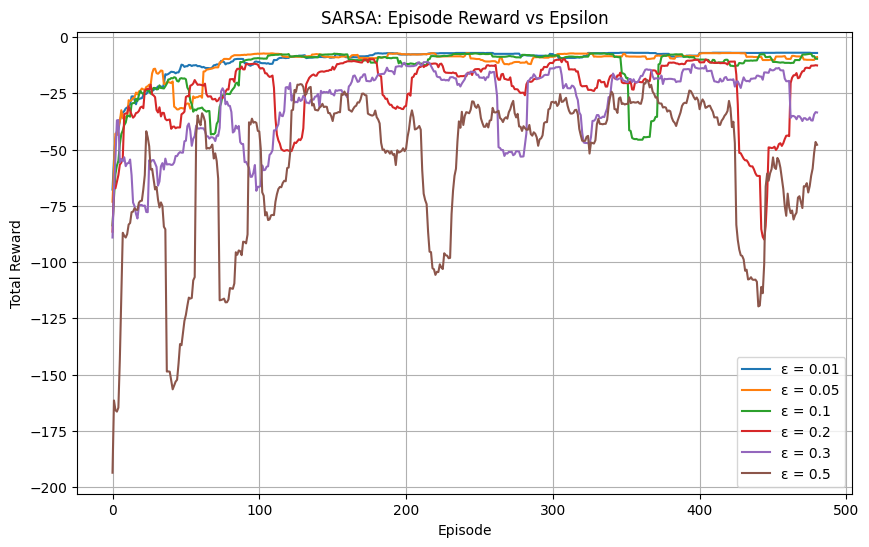

In [106]:
sarsa_results = run_algorithm_for_epsilons(env, sarsa, epsilons=epsilons)
plot_epsilon_comparison(sarsa_results, title="SARSA: Episode Reward vs Epsilon")

In [107]:
for epsilon, rewards in sarsa_results.items():
    avg_last_50 = np.mean(rewards[-50:])
    avg_total = np.mean(rewards)
    print(f"ε = {epsilon:.2f} | Avg reward (last 50 episodes): {avg_last_50:.2f} | Overall avg: {avg_total:.2f}")


ε = 0.01 | Avg reward (last 50 episodes): -7.06 | Overall avg: -11.73
ε = 0.05 | Avg reward (last 50 episodes): -9.60 | Overall avg: -13.02
ε = 0.10 | Avg reward (last 50 episodes): -10.00 | Overall avg: -16.16
ε = 0.20 | Avg reward (last 50 episodes): -27.52 | Overall avg: -24.82
ε = 0.30 | Avg reward (last 50 episodes): -23.96 | Overall avg: -31.32
ε = 0.50 | Avg reward (last 50 episodes): -59.54 | Overall avg: -59.46


In [108]:
# best epsilon as of now is 0.01

**Step 3: Q-Learning Algorithm Template**

In [109]:
def q_learning(env, episodes=500, alpha=0.1, gamma=0.99, epsilon=0.1):
    Q = {}
    for x in range(env.grid_size[0]):
        for y in range(env.grid_size[1]):
            Q[(x, y)] = np.zeros(len(env.actions))

    rewards_per_episode = []

    for ep in range(episodes):
        state = env.reset()
        total_reward = 0

        while True:
            action = epsilon_greedy(Q, state, epsilon)
            next_state, reward, done = env.step(action)

            best_next = np.max(Q[next_state])
            Q[state][action] += alpha * (reward + gamma * best_next - Q[state][action])

            state = next_state
            total_reward += reward

            if done:
                break

        rewards_per_episode.append(total_reward)

    return Q, rewards_per_episode


Training with q_learning | ε = 0.01
Training with q_learning | ε = 0.05
Training with q_learning | ε = 0.1
Training with q_learning | ε = 0.2
Training with q_learning | ε = 0.3
Training with q_learning | ε = 0.5


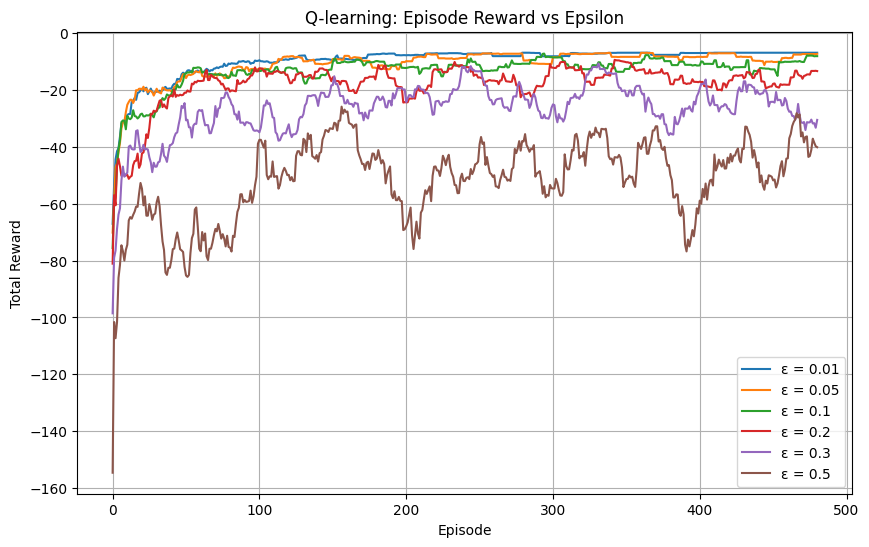

In [110]:
qlearn_results = run_algorithm_for_epsilons(env, q_learning, epsilons=epsilons)
plot_epsilon_comparison(qlearn_results, title="Q-learning: Episode Reward vs Epsilon")

In [111]:
for epsilon, rewards in qlearn_results.items():
    avg_last_50 = np.mean(rewards[-50:])
    avg_total = np.mean(rewards)
    print(f"ε = {epsilon:.2f} | Avg reward (last 50 episodes): {avg_last_50:.2f} | Overall avg: {avg_total:.2f}")

ε = 0.01 | Avg reward (last 50 episodes): -7.00 | Overall avg: -11.46
ε = 0.05 | Avg reward (last 50 episodes): -8.50 | Overall avg: -12.68
ε = 0.10 | Avg reward (last 50 episodes): -10.88 | Overall avg: -15.31
ε = 0.20 | Avg reward (last 50 episodes): -15.70 | Overall avg: -19.77
ε = 0.30 | Avg reward (last 50 episodes): -28.00 | Overall avg: -28.75
ε = 0.50 | Avg reward (last 50 episodes): -43.88 | Overall avg: -54.76


In [112]:
## Best epsilon so far is 0.01
## Best epsilon for both learning method is 0.01
ep= 0.01

**Step 1: Train Both Algorithms**

In [113]:
def train_both_algorithms(env, episodes=500, epsilon=ep, alpha=0.1, gamma=0.99):
    print("Training SARSA...")
    Q_sarsa, rewards_sarsa = sarsa(env, episodes, alpha, gamma, epsilon)

    print("\nTraining Q-learning...")
    Q_qlearn, rewards_qlearn = q_learning(env, episodes, alpha, gamma, epsilon)

    return (Q_sarsa, rewards_sarsa), (Q_qlearn, rewards_qlearn)


**Step 2: Plot Reward Trends**

In [114]:
def plot_learning_curves(rewards_sarsa, rewards_qlearn):
    plt.figure(figsize=(10, 6))
    sm_sarsa = np.convolve(rewards_sarsa, np.ones(20)/20, mode='valid')
    sm_qlearn = np.convolve(rewards_qlearn, np.ones(20)/20, mode='valid')

    plt.plot(sm_sarsa, label="SARSA", color='blue')
    plt.plot(sm_qlearn, label="Q-learning", color='green')
    plt.xlabel("Episode")
    plt.ylabel("Total Reward")
    plt.title("Learning Curves: SARSA vs Q-learning")
    plt.legend()
    plt.grid(True)
    plt.show()


**Step 3: Print Summary Statistics**

In [115]:
def print_summary_stats(rewards, name=""):
    avg_total = np.mean(rewards)
    avg_last_50 = np.mean(rewards[-50:])
    print(f"{name}:\n  Avg Reward (All): {avg_total:.2f}\n  Avg Reward (Last 50): {avg_last_50:.2f}")


**Run**

In [116]:
env = GridWorld()

(sarsa_Q, sarsa_rewards), (qlearn_Q, qlearn_rewards) = train_both_algorithms(env)


Training SARSA...

Training Q-learning...


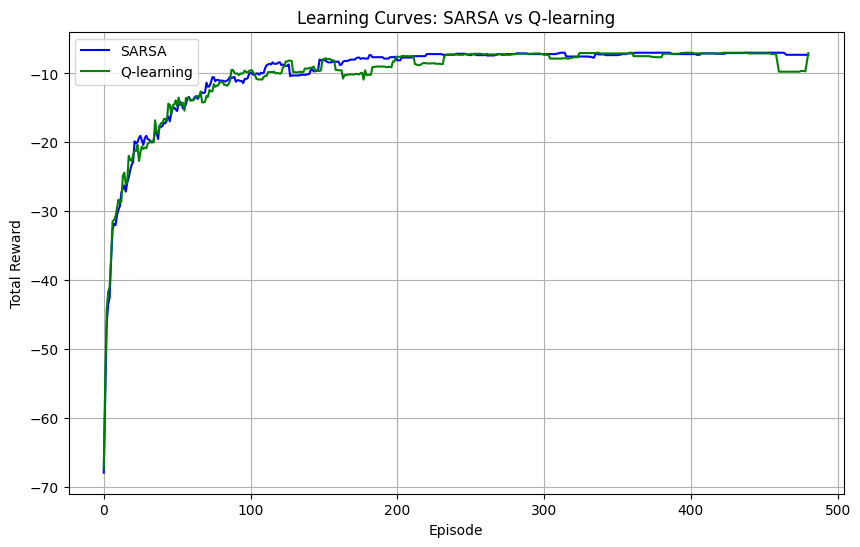

In [117]:

# Plot learning trends
plot_learning_curves(sarsa_rewards, qlearn_rewards)

In [118]:
# Print summary
print_summary_stats(sarsa_rewards, name="SARSA")
print_summary_stats(qlearn_rewards, name="Q-learning")

SARSA:
  Avg Reward (All): -11.46
  Avg Reward (Last 50): -7.12
Q-learning:
  Avg Reward (All): -11.70
  Avg Reward (Last 50): -8.16


###**How does the sum of rewards over an episode behave for each method?**

Over the course of training, the sum of rewards per episode improves for both methods, showing that both SARSA and Q-learning are learning to avoid negative rewards and reach terminal states more efficiently.

From the reward statistics:

**SARSA:**

Average reward across all episodes: **-11.46**

Average reward in the last 50 episodes: **-7.12**

**Q-learning:**

Average reward across all episodes: **-11.70**

Average reward in the last 50 episodes: **-8.16**

These results show that:

SARSA ends up performing slightly better in the final episodes, achieving a less negative average reward compared to Q-learning.

This is consistent with SARSA's on-policy behavior, which tends to learn safer, more stable policies — even if it takes longer.

Q-learning, being off-policy, often converges faster but may adopt slightly riskier paths early on, leading to more variability or less stable convergence.

Overall, SARSA's smoother improvement and higher final reward indicate that, in this specific environment, its cautious updates led to a more robust policy by the end of training.

**Visualizing the Learned Policy and Trajectories**

Step 1: Extract and Display Final Policy (Arrow Grid)

In [119]:
def display_policy(Q, grid_size=(5, 5), terminal_states=[], red_states=[]):
    action_map = {
        0: '↑',
        1: '↓',
        2: '←',
        3: '→'
    }

    print("\nPolicy Grid:")
    for y in reversed(range(grid_size[1])):  # start from top row
        row = ''
        for x in range(grid_size[0]):
            state = (x, y)
            if state in terminal_states:
                row += ' T  '
            elif state in red_states:
                row += ' R  '
            else:
                action = np.argmax(Q[state])
                row += f' {action_map[action]}  '
        print(row)


In [120]:
#Sarsa
display_policy(sarsa_Q, terminal_states=[(4, 0), (4, 4)], red_states=[(2, 0), (2, 1), (2, 3), (2, 4)])



Policy Grid:
 ↑   ←   R   →   T  
 ↑   ←   R   →   ↑  
 →   →   →   ↑   ↑  
 ↑   ↑   R   →   ↓  
 ↑   ↑   R   →   T  


In [121]:
#Q-learning
display_policy(qlearn_Q, terminal_states=[(4, 0), (4, 4)], red_states=[(2, 0), (2, 1), (2, 3), (2, 4)])


Policy Grid:
 ↓   ←   R   →   T  
 →   ↑   R   →   ↑  
 →   →   →   ↓   ↑  
 ↑   ↑   R   ↓   ↓  
 →   ↑   R   →   T  


Step 2: Simulate Agent Trajectory Using Learned Policy

In [122]:
def simulate_trajectory(env, Q, max_steps=50):
    state = env.reset()
    trajectory = [state]

    for _ in range(max_steps):
        action = np.argmax(Q[state])
        next_state, _, done = env.step(action)
        trajectory.append(next_state)
        if done:
            break
        state = next_state

    return trajectory


In [123]:
# Pretty Print Trajectory on Grid
def print_trajectory_on_grid(trajectory, grid_size=(5, 5), terminal_states=[], red_states=[]):
    grid = [['.' for _ in range(grid_size[0])] for _ in range(grid_size[1])]

    for x, y in terminal_states:
        grid[y][x] = 'T'
    for x, y in red_states:
        grid[y][x] = 'R'

    for i, (x, y) in enumerate(trajectory):
        if grid[y][x] in ['T', 'R']:
            continue
        grid[y][x] = '*' if i == 0 else 'o'

    print("\nTrajectory on Grid (bottom-left is (0,0)):")
    for y in reversed(range(grid_size[1])):
        print(' '.join(grid[y]))


In [124]:
##Sarsa
trajectory_Sarsa = simulate_trajectory(env, sarsa_Q)
print_trajectory_on_grid(trajectory_Sarsa, terminal_states=[(4, 0), (4, 4)], red_states=[(2, 0), (2, 1), (2, 3), (2, 4)])



Trajectory on Grid (bottom-left is (0,0)):
. . R . T
. . R o o
o o o o .
o . R . .
* . R . T


In [125]:
## Q-learning
trajectory_Q_learn = simulate_trajectory(env, qlearn_Q)
print_trajectory_on_grid(trajectory_Q_learn, terminal_states=[(4, 0), (4, 4)], red_states=[(2, 0), (2, 1), (2, 3), (2, 4)])



Trajectory on Grid (bottom-left is (0,0)):
. . R . T
. . R . .
. o o o .
. o R o .
* o R o T


In [126]:
def plot_trajectory(trajectory, grid_size=(5, 5), terminal_states=[], red_states=[], start=(0, 0), method_name="Sarsa"):
    fig, ax = plt.subplots(figsize=(6, 6))

    ax.set_xlim(-0.5, grid_size[0] - 0.5)
    ax.set_ylim(-0.5, grid_size[1] - 0.5)
    ax.set_xticks(range(grid_size[0]))
    ax.set_yticks(range(grid_size[1]))
    ax.set_xticks([x - 0.5 for x in range(1, grid_size[0])], minor=True)
    ax.set_yticks([y - 0.5 for y in range(1, grid_size[1])], minor=True)
    ax.grid(which='minor', color='black', linewidth=1)

    # Plot red states
    for (x, y) in red_states:
        ax.add_patch(plt.Rectangle((x - 0.5, y - 0.5), 1, 1, color='red', alpha=0.6))

    # Plot terminal states
    for (x, y) in terminal_states:
        ax.add_patch(plt.Rectangle((x - 0.5, y - 0.5), 1, 1, color='black'))

    # Plot start state
    x0, y0 = start
    ax.add_patch(plt.Rectangle((x0 - 0.5, y0 - 0.5), 1, 1, color='blue', alpha=0.5))

    # Plot trajectory path
    xs, ys = zip(*trajectory)
    ax.plot(xs, ys, marker='o', color='green', linestyle='-', linewidth=2, markersize=6)
    ax.scatter(xs[0], ys[0], color='blue', label='Start', s=100)
    ax.scatter(xs[-1], ys[-1], color='purple', label='End', s=100)

    ax.set_title(f"Agent Trajectory: {method_name}")
    ax.legend()
    ax.set_aspect('equal')
    plt.gca().invert_yaxis()  # Match gridworld (0,0) at bottom-left
    plt.show()


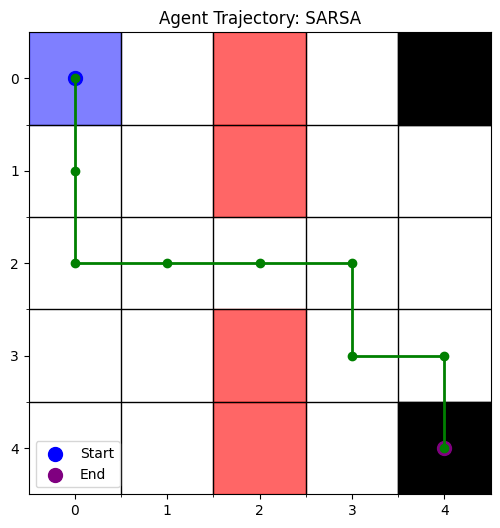

In [127]:
# Sarsa
trajectory_Sarsa = simulate_trajectory( env, sarsa_Q)
plot_trajectory(trajectory_Sarsa,
                grid_size=(5, 5),
                terminal_states=[(4, 0), (4, 4)],
                red_states=[(2, 0), (2, 1), (2, 3), (2, 4)],
                start=(0, 0),
                method_name="SARSA")


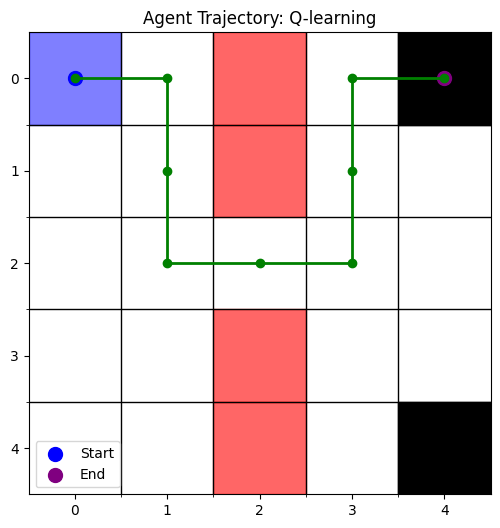

In [128]:
# Q-learning
trajectory_Q_learn = simulate_trajectory(env, qlearn_Q)
plot_trajectory(trajectory_Q_learn,
                grid_size=(5, 5),
                terminal_states=[(4, 0), (4, 4)],
                red_states=[(2, 0), (2, 1), (2, 3), (2, 4)],
                start=(0, 0),
                method_name="Q-learning")

In [129]:
def plot_both_trajectories(traj_sarsa, traj_qlearn,
                           grid_size=(5, 5),
                           terminal_states=[],
                           red_states=[],
                           start=(0, 0)):
    fig, ax = plt.subplots(figsize=(6, 6))

    ax.set_xlim(-0.5, grid_size[0] - 0.5)
    ax.set_ylim(-0.5, grid_size[1] - 0.5)
    ax.set_xticks(range(grid_size[0]))
    ax.set_yticks(range(grid_size[1]))
    ax.set_xticks([x - 0.5 for x in range(1, grid_size[0])], minor=True)
    ax.set_yticks([y - 0.5 for y in range(1, grid_size[1])], minor=True)
    ax.grid(which='minor', color='black', linewidth=1)

    # Red states
    for (x, y) in red_states:
        ax.add_patch(plt.Rectangle((x - 0.5, y - 0.5), 1, 1, color='red', alpha=0.5))

    # Terminal states
    for (x, y) in terminal_states:
        ax.add_patch(plt.Rectangle((x - 0.5, y - 0.5), 1, 1, color='black'))

    # Start state
    x0, y0 = start
    ax.add_patch(plt.Rectangle((x0 - 0.5, y0 - 0.5), 1, 1, color='blue', alpha=0.4))

    # Plot SARSA trajectory
    xs_s, ys_s = zip(*traj_sarsa)
    ax.plot(xs_s, ys_s, marker='o', color='blue', linestyle='-', linewidth=2, label='SARSA')

    # Plot Q-learning trajectory
    xs_q, ys_q = zip(*traj_qlearn)
    ax.plot(xs_q, ys_q, marker='o', color='green', linestyle='--', linewidth=2, label='Q-learning')

    # Mark start and end points
    ax.scatter(xs_s[0], ys_s[0], color='blue', s=100, marker='s')
    ax.scatter(xs_s[-1], ys_s[-1], color='navy', s=100, label='SARSA End')

    ax.scatter(xs_q[-1], ys_q[-1], color='darkgreen', s=100, label='Q-learning End')

    ax.set_title("SARSA vs Q-learning Trajectory Comparison")
    ax.legend()
    ax.set_aspect('equal')
    plt.gca().invert_yaxis()  # bottom-left is (0, 0)
    plt.show()


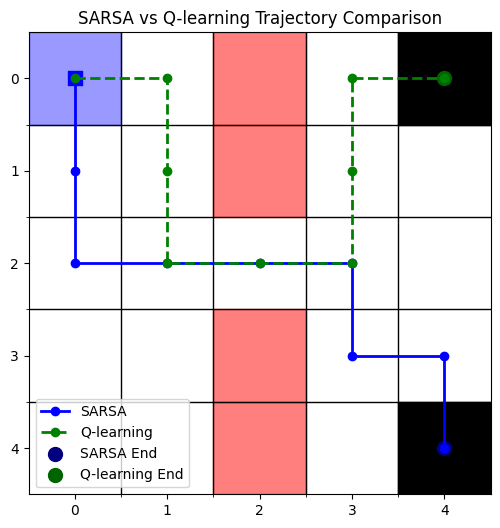

In [130]:
traj_sarsa = simulate_trajectory(env, sarsa_Q)
traj_qlearn = simulate_trajectory(env, qlearn_Q)

plot_both_trajectories(trajectory_Sarsa, trajectory_Q_learn,
                       grid_size=(5, 5),
                       terminal_states=[(4, 0), (4, 4)],
                       red_states=[(2, 0), (2, 1), (2, 3), (2, 4)],
                       start=(0, 0))


###**Are they different or similar?**

**Trajectory Comparison:**

The comparative trajectory plot shows the paths taken by the agent using policies learned via **SARSA** (blue) and **Q-learning** (green).

**SARSA** follows a slightly longer and safer path, avoiding red states by going around them more cautiously.

**Q-learning**, on the other hand, identifies a shorter, more direct route through the grid that reaches the goal more quickly while still avoiding red penalties.

**Why or why not?**

These differences are due to the on-policy nature of **SARSA** vs. the off-policy strategy of **Q-learning**:

**SARSA** updates are based on the actual actions taken, making it more conservative and cautious in early learning stages.

**Q-learning** updates using the maximum possible future reward, making it more aggressive in policy updates.